In [1]:
ls 

pod_decomposed_df_100ms_1core.csv      pod_decomposed_df_200ms_apiserver.csv
pod_decomposed_df_100ms_apiserver.csv  pod_decomposed_df_200ms.csv
pod_decomposed_df_100ms.csv            pod_decomposed_df_200ms_hybrid.csv
pod_decomposed_df_100ms_hybrid.csv     pod_decomposed_df_50ms_1core.csv
pod_decomposed_df_10ms_1core.csv       pod_decomposed_df_50ms_apiserver.csv
pod_decomposed_df_10ms_apiserver.csv   pod_decomposed_df_50ms.csv
pod_decomposed_df_10ms.csv             pod_decomposed_df_50ms_hybrid.csv
pod_decomposed_df_10ms_hybrid.csv      pod_ecdf_overlay99.pdf
pod_decomposed_df_1s_1core.csv         pod_ecdf_overlay99.png
pod_decomposed_df_1s_apiserver.csv     pod_ecdf_overlay.pdf
pod_decomposed_df_1s.csv               pod_ecdf_overlay.png
pod_decomposed_df_1s_hybrid.csv        Untitled3.ipynb
pod_decomposed_df_200ms_1core.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Delays with data: ['10ms', '50ms', '100ms', '200ms', '1s']
  [OK]   Hybrid / 10ms — 370 samples, median=126.1ms, p99=259.2ms
  [OK]   Local / 10ms — 386 samples, median=163.0ms, p99=371.5ms
  [OK]   Local 1core / 10ms — 393 samples, median=171.5ms, p99=377.0ms
  [OK]   Hybrid / 50ms — 140 samples, median=100.0ms, p99=270.3ms
  [OK]   Local / 50ms — 323 samples, median=225.0ms, p99=602.5ms
  [OK]   Local 1core / 50ms — 222 samples, median=112.2ms, p99=263.2ms
  [OK]   Hybrid / 100ms — 41 samples, median=96.1ms, p99=133.0ms
  [OK]   Local / 100ms — 79 samples, median=114.4ms, p99=238.3ms
  [OK]   Local 1core / 100ms — 93 samples, median=113.6ms, p99=172.9ms
  [OK]   Hybrid / 200ms — 21 samples, median=96.7ms, p99=141.1ms
  [OK]   Local / 200ms — 22 samples, median=118.7ms, p99=158.1ms
  [OK]   Local 1core / 200ms — 27 samples, median=102.6ms, p99=154.6ms
  [OK]   Hybrid / 1s — 10 samples, median=94.1ms, p99=134.0ms
  [OK]   Local / 1s — 12 samples, median=100.3ms, p99=111.3ms
  [OK]   Lo

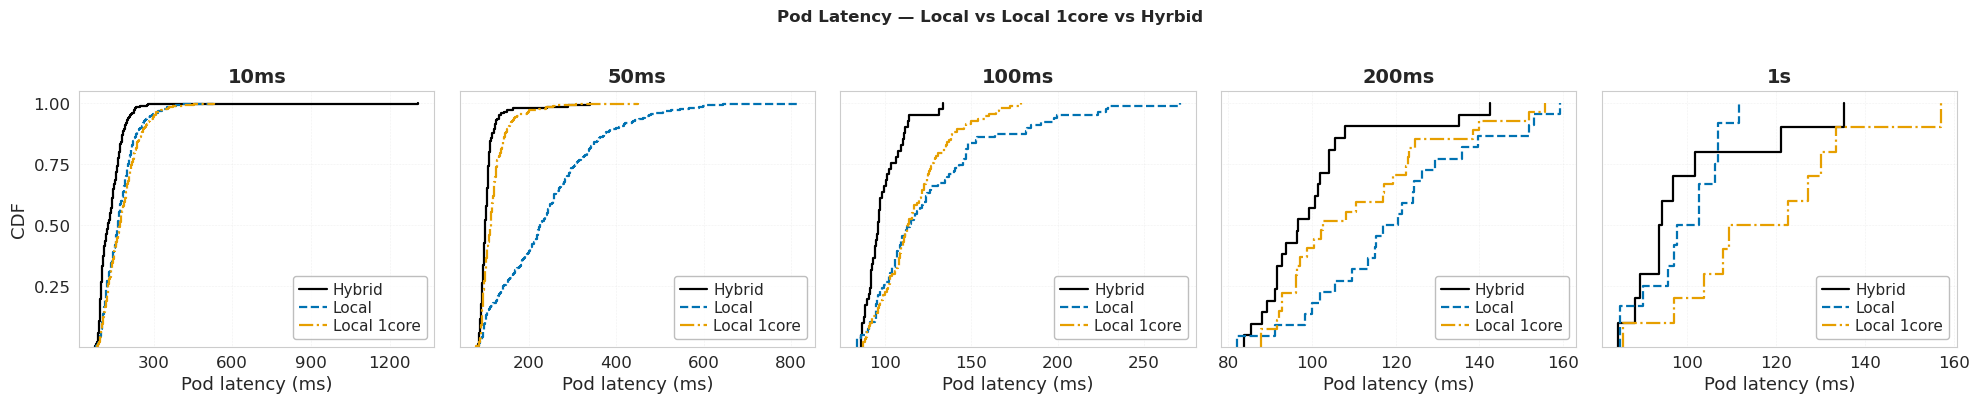

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
import os

# ─── STYLE ────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "DejaVu Serif"],
    "font.size":          13,
    "axes.titlesize":     14,
    "axes.labelsize":     13,
    "xtick.labelsize":    12,
    "ytick.labelsize":    12,
    "legend.fontsize":    11,
    "legend.framealpha":  0.85,
    "legend.edgecolor":   "0.7",
    "axes.linewidth":     0.8,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "grid.linewidth":     0.4,
    "grid.alpha":         0.4,
    "grid.color":         "0.75",
    "lines.linewidth":    1.6,
    "pdf.fonttype":       42,
    "ps.fonttype":        42,
})

sns.set_style("whitegrid")

# ─── PALETTE ──────────────────────────────────────────────────────────
COLORS     = ["#000000","#0072B2","#E69F00" ]   # noir, bleu, orange
LINESTYLES = ["-",       "--",      "-."]
LABELS     = ["Hybrid",  "Local", "Local 1core"]

# ─── CONFIG ───────────────────────────────────────────────────────────
DELAYS = ["10ms", "50ms", "100ms", "200ms", "1s"]

DATA_DIR = "."

FILES = {
    "Local": {
        d: os.path.join(DATA_DIR, f"pod_decomposed_df_{d}.csv") for d in DELAYS
    },
    "Hybrid": {
        d: os.path.join(DATA_DIR, f"pod_decomposed_df_{d}_hybrid.csv") for d in DELAYS
    },
    "Local 1core": {
        d: os.path.join(DATA_DIR, f"pod_decomposed_df_{d}_1core.csv") for d in DELAYS
    },
}

MODES = ["Hybrid",  "Local","Local 1core"]

# ─── CHARGEMENT ───────────────────────────────────────────────────────
def load_series(filepath):
    if filepath is None or not os.path.exists(filepath):
        return None
    df = pd.read_csv(filepath)
    return df["duration_ms"].dropna()

# ─── STYLE AXES ───────────────────────────────────────────────────────
def style_ax(ax):
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5, prune='both'))
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5, prune='both'))
    ax.tick_params(direction='out', length=3, width=0.6, pad=3)
    ax.grid(True, linestyle=':', linewidth=0.4, color='0.75')

# ─── CHECK AVAILABLE FILES ────────────────────────────────────────────
available_delays = []
for d in DELAYS:
    has_any = any(os.path.exists(FILES[m][d]) for m in MODES)
    if has_any:
        available_delays.append(d)

print(f"Delays with data: {available_delays}")
if not available_delays:
    raise RuntimeError("Aucun fichier trouvé — vérifiez DATA_DIR et les noms de fichiers.")

# ─── FIGURE ───────────────────────────────────────────────────────────
n = len(available_delays)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), sharey=True)
if n == 1:
    axes = [axes]

for c, delay in enumerate(available_delays):
    ax = axes[c]

    for i, mode in enumerate(MODES):
        filepath = FILES[mode][delay]
        data = load_series(filepath)
        if data is None:
            print(f"  [SKIP] {mode} / {delay} — file not found")
            continue

        print(f"  [OK]   {mode} / {delay} — {len(data)} samples, median={data.median():.1f}ms, p99={data.quantile(0.99):.1f}ms")

        sns.ecdfplot(
            data=data,
            ax=ax,
            color=COLORS[i],
            linestyle=LINESTYLES[i],
            linewidth=1.6,
            label=LABELS[i],
        )

    ax.set_title(delay, fontweight='bold')
    ax.set_xlabel("Pod latency (ms)")

    if c == 0:
        ax.set_ylabel("CDF")

    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.25))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{v:.2f}"))

    ax.legend(
        loc='lower right',
        handlelength=1.8,
        borderpad=0.4,
        labelspacing=0.2,
        handletextpad=0.4,
    )

    style_ax(ax)

# ─── TITRE ────────────────────────────────────────────────────────────
fig.suptitle(
    "Pod Latency — Local vs Local 1core vs Hyrbid",
    fontsize=12,
    fontweight='bold',
    y=1.01,
)

plt.tight_layout()

# ─── EXPORT ───────────────────────────────────────────────────────────
out_pdf = "pod_ecdf_overlay.pdf"
out_png = "pod_ecdf_overlay.png"

plt.savefig(out_pdf, dpi=300, bbox_inches="tight")
plt.savefig(out_png, dpi=300, bbox_inches="tight")

print(f"\n✓ Saved: {out_pdf}")
print(f"✓ Saved: {out_png}")

Delays with data: ['10ms', '50ms', '100ms', '200ms', '1s']
[OK] Hybrid/10ms -> p99=259.2ms
[OK] Local/10ms -> p99=371.5ms
[OK] Local 1core/10ms -> p99=377.0ms
[OK] Local Apiserver/10ms -> p99=366.5ms
[OK] Hybrid/50ms -> p99=270.3ms
[OK] Local/50ms -> p99=602.5ms
[OK] Local 1core/50ms -> p99=263.2ms
[OK] Local Apiserver/50ms -> p99=268.0ms
[OK] Hybrid/100ms -> p99=133.0ms
[OK] Local/100ms -> p99=238.3ms
[OK] Local 1core/100ms -> p99=172.9ms
[OK] Local Apiserver/100ms -> p99=261.8ms
[OK] Hybrid/200ms -> p99=141.1ms
[OK] Local/200ms -> p99=158.1ms
[OK] Local 1core/200ms -> p99=154.6ms
[OK] Local Apiserver/200ms -> p99=189.7ms
[OK] Hybrid/1s -> p99=134.0ms
[OK] Local/1s -> p99=111.3ms
[OK] Local 1core/1s -> p99=154.9ms
[OK] Local Apiserver/1s -> p99=155.1ms

✓ Saved: pod_ecdf_overlay99.pdf
✓ Saved: pod_ecdf_overlay99.png


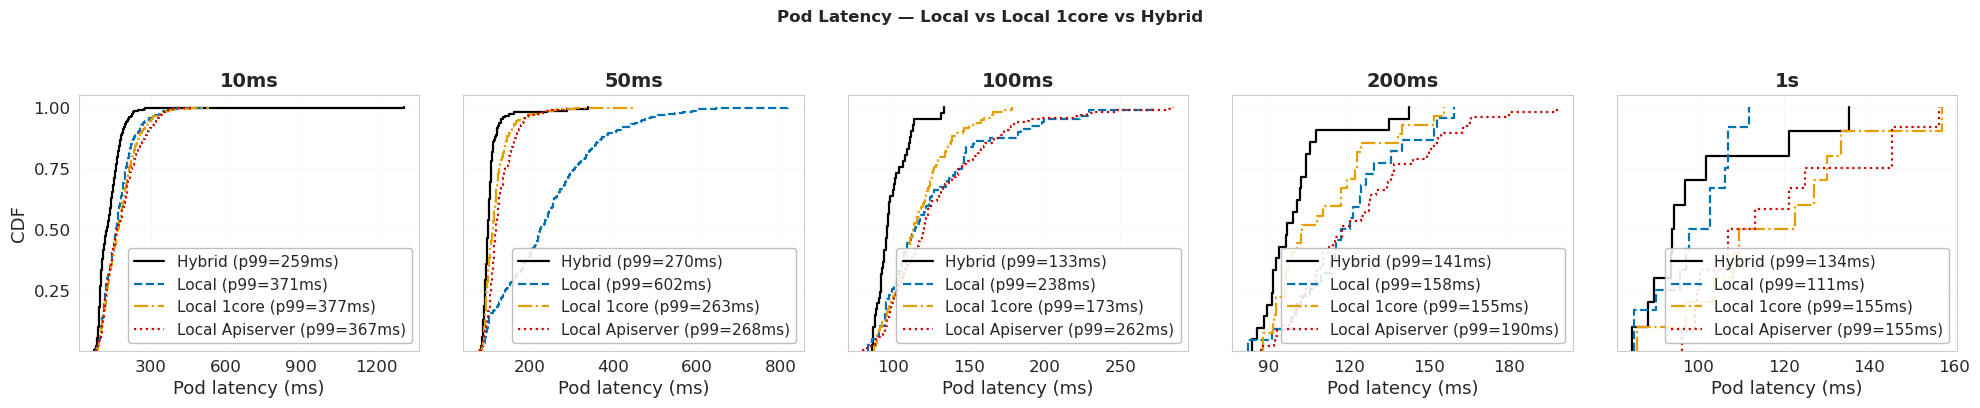

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
import os

# ─── STYLE ────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "DejaVu Serif"],
    "font.size":          13,
    "axes.titlesize":     14,
    "axes.labelsize":     13,
    "xtick.labelsize":    12,
    "ytick.labelsize":    12,
    "legend.fontsize":    11,
    "legend.framealpha":  0.85,
    "legend.edgecolor":   "0.7",
    "axes.linewidth":     0.8,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "grid.linewidth":     0.4,
    "grid.alpha":         0.4,
    "grid.color":         "0.75",
    "lines.linewidth":    1.6,
    "pdf.fonttype":       42,
    "ps.fonttype":        42,
})

sns.set_style("whitegrid")

# ─── CONFIG ───────────────────────────────────────────────────────────
COLORS     = ["#000000", "#0072B2", "#E69F00", "#CC0000"]
LINESTYLES = ["-",       "--",      "-.",      ":"]
LABELS     = ["Hybrid",  "Local", "Local 1core","Local Apiserver"]

MODES      = ["Hybrid",  "Local", "Local 1core","Local Apiserver"]

DELAYS = ["10ms", "50ms", "100ms", "200ms", "1s"]
DATA_DIR = "."

FILES = {
    "Local": {
        d: os.path.join(DATA_DIR, f"pod_decomposed_df_{d}.csv") for d in DELAYS
    },
    "Hybrid": {
        d: os.path.join(DATA_DIR, f"pod_decomposed_df_{d}_hybrid.csv") for d in DELAYS
    },
    "Local 1core": {
        d: os.path.join(DATA_DIR, f"pod_decomposed_df_{d}_1core.csv") for d in DELAYS
    },
"Local Apiserver": {
        d: os.path.join(DATA_DIR, f"pod_decomposed_df_{d}_apiserver.csv") for d in DELAYS
    }
}

# ─── LOAD ─────────────────────────────────────────────────────────────
def load_series(filepath):
    if filepath is None or not os.path.exists(filepath):
        return None
    df = pd.read_csv(filepath)
    return df["duration_ms"].dropna()

# ─── STYLE AX ──────────────────────────────────────────────────────────
def style_ax(ax):
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5, prune='both'))
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5, prune='both'))
    ax.tick_params(direction='out', length=3, width=0.6, pad=3)
    ax.grid(True, linestyle=':', linewidth=0.4, color='0.75')

# ─── CHECK FILES ───────────────────────────────────────────────────────
available_delays = [
    d for d in DELAYS
    if any(os.path.exists(FILES[m][d]) for m in MODES)
]

print(f"Delays with data: {available_delays}")
if not available_delays:
    raise RuntimeError("Aucun fichier trouvé")

# ─── FIGURE ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    1, len(available_delays),
    figsize=(4 * len(available_delays), 4),
    sharey=True
)

if len(available_delays) == 1:
    axes = [axes]

# ─── PLOT ─────────────────────────────────────────────────────────────
for c, delay in enumerate(available_delays):
    ax = axes[c]

    for i, mode in enumerate(MODES):
        filepath = FILES[mode][delay]
        data = load_series(filepath)

        if data is None or len(data) == 0:
            print(f"[SKIP] {mode} / {delay}")
            continue

        p99 = data.quantile(0.99)

        print(f"[OK] {mode}/{delay} -> p99={p99:.1f}ms")

        sns.ecdfplot(
            data=data,
            ax=ax,
            color=COLORS[i],
            linestyle=LINESTYLES[i],
            linewidth=1.6,
            label=f"{LABELS[i]} (p99={p99:.0f}ms)"
        )

    ax.set_title(delay, fontweight='bold')
    ax.set_xlabel("Pod latency (ms)")

    if c == 0:
        ax.set_ylabel("CDF")

    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.25))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{v:.2f}"))

    ax.legend(loc='lower right')
    style_ax(ax)

# ─── TITLE ────────────────────────────────────────────────────────────
fig.suptitle(
    "Pod Latency — Local vs Local 1core vs Hybrid",
    fontsize=12,
    fontweight='bold',
    y=1.02,
)

plt.tight_layout()

# ─── EXPORT ───────────────────────────────────────────────────────────
out_pdf = "pod_ecdf_overlay99.pdf"
out_png = "pod_ecdf_overlay99.png"

plt.savefig(out_pdf, dpi=300, bbox_inches="tight")
plt.savefig(out_png, dpi=300, bbox_inches="tight")

print(f"\n✓ Saved: {out_pdf}")
print(f"✓ Saved: {out_png}")

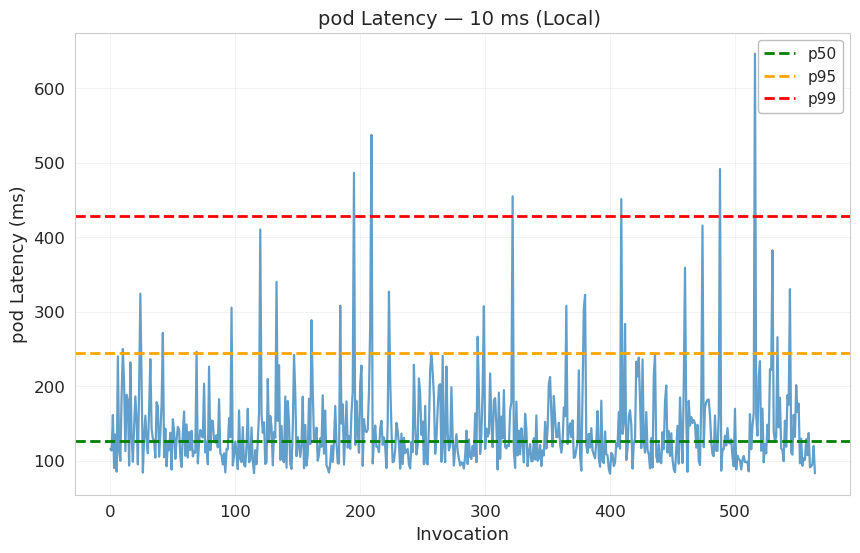

In [13]:
import matplotlib.pyplot as plt
import numpy as np

pod_10 = pd.read_csv("pod_df_10ms.csv")
# Récupérer les durées
durations = pod_10['duration_ms'].dropna().values

# Calcul des percentiles
p50 = np.percentile(durations, 50)
p95 = np.percentile(durations, 95)
p99 = np.percentile(durations, 99)

plt.figure(figsize=(10,6))

# Tracer les durées individuelles
plt.plot(pod_10.index, durations, alpha=0.7)

# Ajouter les lignes horizontales pour les percentiles
plt.axhline(p50, color='green', linestyle='--', linewidth=2, label='p50')
plt.axhline(p95, color='orange', linestyle='--', linewidth=2, label='p95')
plt.axhline(p99, color='red', linestyle='--', linewidth=2, label='p99')

plt.xlabel("Invocation")
plt.ylabel("pod Latency (ms)")
plt.grid(True)
plt.legend()
plt.title("pod Latency — 10 ms (Local) ")
plt.savefig("pod_latencies_percentiles_10ms.pdf", format="pdf")
plt.show()

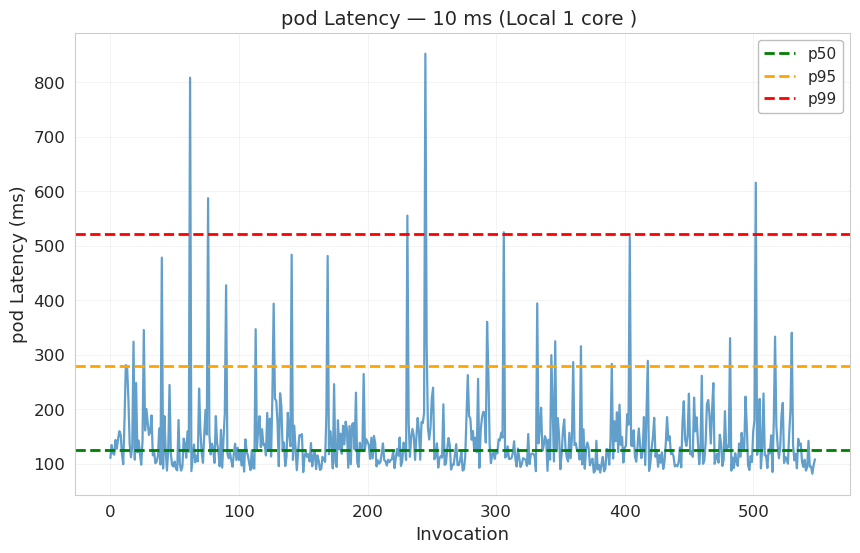

In [14]:
import matplotlib.pyplot as plt
import numpy as np

pod_10_core = pd.read_csv("pod_df_10ms_1core.csv")
# Récupérer les durées
durations = pod_10_core['duration_ms'].dropna().values

# Calcul des percentiles
p50 = np.percentile(durations, 50)
p95 = np.percentile(durations, 95)
p99 = np.percentile(durations, 99)

plt.figure(figsize=(10,6))

# Tracer les durées individuelles
plt.plot(pod_10_core.index, durations, alpha=0.7)

# Ajouter les lignes horizontales pour les percentiles
plt.axhline(p50, color='green', linestyle='--', linewidth=2, label='p50')
plt.axhline(p95, color='orange', linestyle='--', linewidth=2, label='p95')
plt.axhline(p99, color='red', linestyle='--', linewidth=2, label='p99')

plt.xlabel("Invocation")
plt.ylabel("pod Latency (ms)")
plt.grid(True)
plt.legend()
plt.title("pod Latency — 10 ms (Local 1 core ) ")
plt.savefig("pod_latencies_percentiles_10ms_core.pdf", format="pdf")
plt.show()

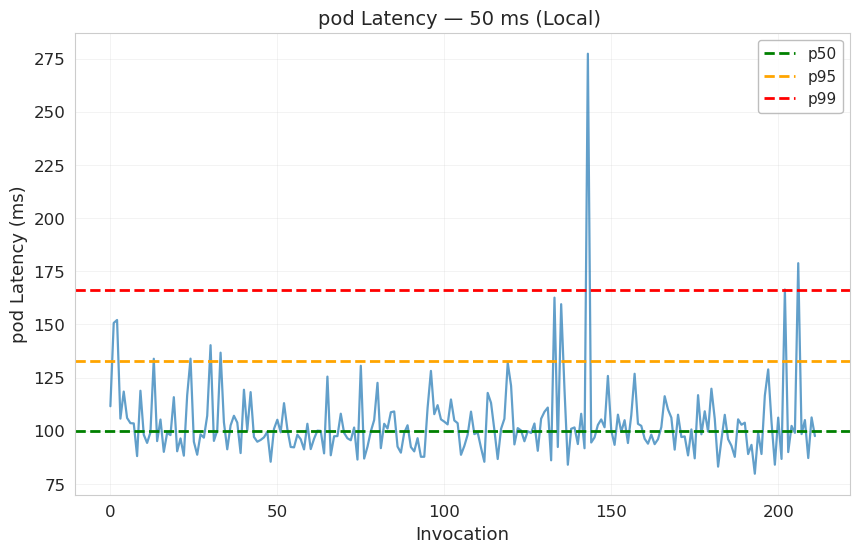

In [18]:
import matplotlib.pyplot as plt
import numpy as np

pod_50 = pd.read_csv("pod_df_50ms.csv")
# Récupérer les durées
durations = pod_50['duration_ms'].dropna().values

# Calcul des percentiles
p50 = np.percentile(durations, 50)
p95 = np.percentile(durations, 95)
p99 = np.percentile(durations, 99)

plt.figure(figsize=(10,6))

# Tracer les durées individuelles
plt.plot(pod_50.index, durations, alpha=0.7)

# Ajouter les lignes horizontales pour les percentiles
plt.axhline(p50, color='green', linestyle='--', linewidth=2, label='p50')
plt.axhline(p95, color='orange', linestyle='--', linewidth=2, label='p95')
plt.axhline(p99, color='red', linestyle='--', linewidth=2, label='p99')

plt.xlabel("Invocation")
plt.ylabel("pod Latency (ms)")
plt.grid(True)
plt.legend()
plt.title("pod Latency — 50 ms (Local) ")
plt.savefig("pod_latencies_percentiles_50ms.pdf", format="pdf")
plt.show()

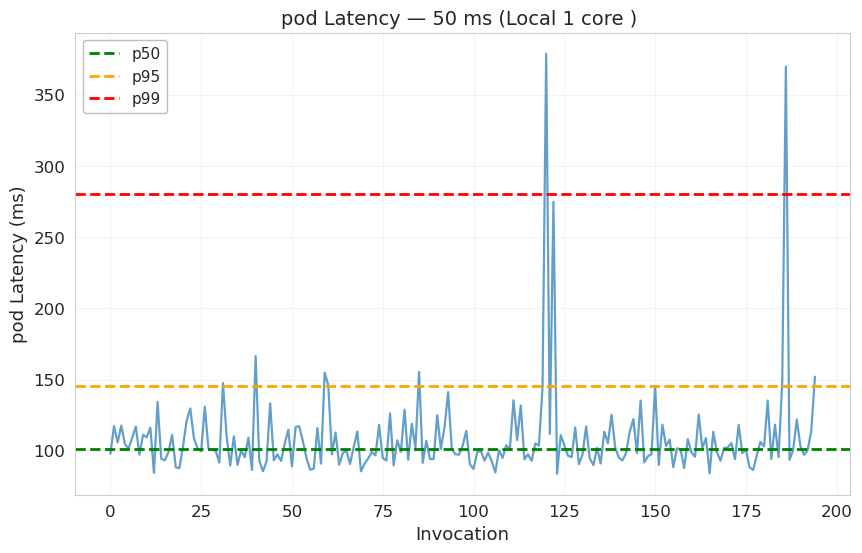

In [19]:
import matplotlib.pyplot as plt
import numpy as np

pod_50_core = pd.read_csv("pod_df_50ms_1core.csv")
# Récupérer les durées
durations = pod_50_core['duration_ms'].dropna().values

# Calcul des percentiles
p50 = np.percentile(durations, 50)
p95 = np.percentile(durations, 95)
p99 = np.percentile(durations, 99)

plt.figure(figsize=(10,6))

# Tracer les durées individuelles
plt.plot(pod_50_core.index, durations, alpha=0.7)

# Ajouter les lignes horizontales pour les percentiles
plt.axhline(p50, color='green', linestyle='--', linewidth=2, label='p50')
plt.axhline(p95, color='orange', linestyle='--', linewidth=2, label='p95')
plt.axhline(p99, color='red', linestyle='--', linewidth=2, label='p99')

plt.xlabel("Invocation")
plt.ylabel("pod Latency (ms)")
plt.grid(True)
plt.legend()
plt.title("pod Latency — 50 ms (Local 1 core ) ")
plt.savefig("pod_latencies_percentiles_50ms_core.pdf", format="pdf")
plt.show()

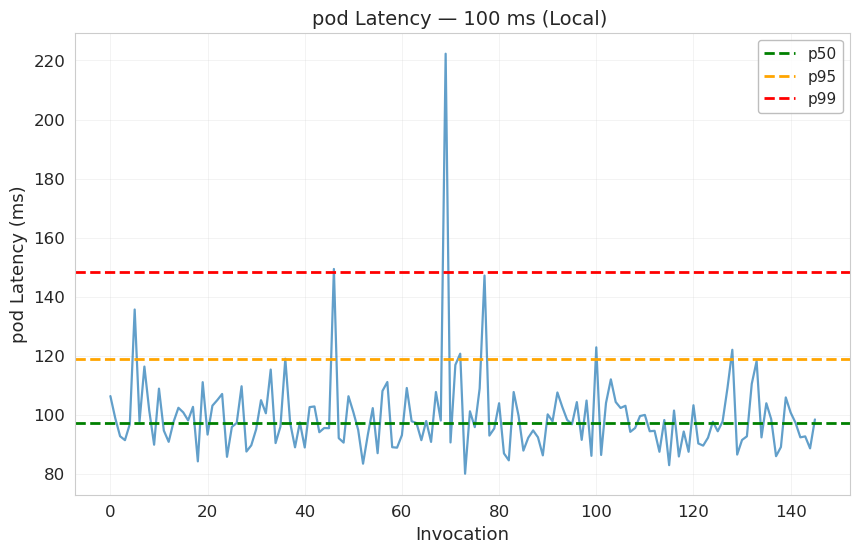

In [16]:
import matplotlib.pyplot as plt
import numpy as np

pod_100 = pd.read_csv("pod_df_100ms.csv")
# Récupérer les durées
durations = pod_100['duration_ms'].dropna().values

# Calcul des percentiles
p50 = np.percentile(durations, 50)
p95 = np.percentile(durations, 95)
p99 = np.percentile(durations, 99)

plt.figure(figsize=(10,6))

# Tracer les durées individuelles
plt.plot(pod_100.index, durations, alpha=0.7)

# Ajouter les lignes horizontales pour les percentiles
plt.axhline(p50, color='green', linestyle='--', linewidth=2, label='p50')
plt.axhline(p95, color='orange', linestyle='--', linewidth=2, label='p95')
plt.axhline(p99, color='red', linestyle='--', linewidth=2, label='p99')

plt.xlabel("Invocation")
plt.ylabel("pod Latency (ms)")
plt.grid(True)
plt.legend()
plt.title("pod Latency — 100 ms (Local) ")
plt.savefig("pod_latencies_percentiles_100ms.pdf", format="pdf")
plt.show()

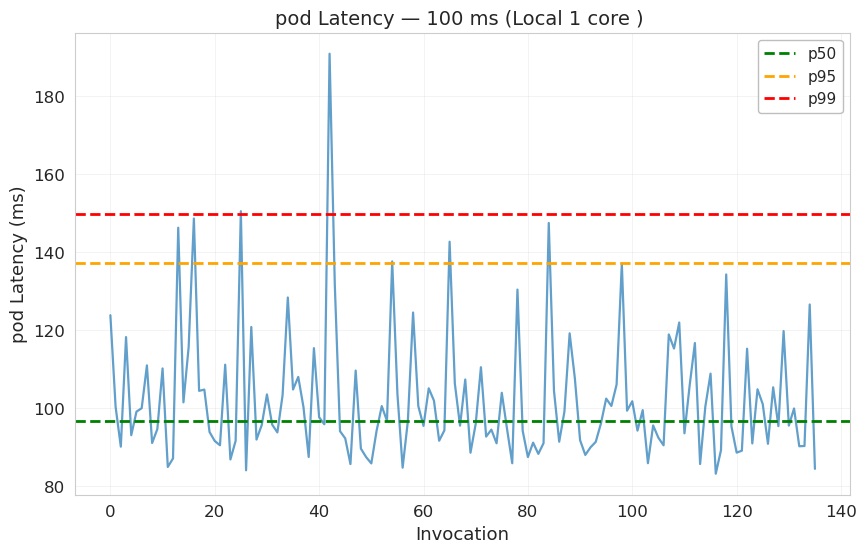

In [17]:
import matplotlib.pyplot as plt
import numpy as np

pod_100_core = pd.read_csv("pod_df_100ms_1core.csv")
# Récupérer les durées
durations = pod_100_core['duration_ms'].dropna().values

# Calcul des percentiles
p50 = np.percentile(durations, 50)
p95 = np.percentile(durations, 95)
p99 = np.percentile(durations, 99)

plt.figure(figsize=(10,6))

# Tracer les durées individuelles
plt.plot(pod_100_core.index, durations, alpha=0.7)

# Ajouter les lignes horizontales pour les percentiles
plt.axhline(p50, color='green', linestyle='--', linewidth=2, label='p50')
plt.axhline(p95, color='orange', linestyle='--', linewidth=2, label='p95')
plt.axhline(p99, color='red', linestyle='--', linewidth=2, label='p99')

plt.xlabel("Invocation")
plt.ylabel("pod Latency (ms)")
plt.grid(True)
plt.legend()
plt.title("pod Latency — 100 ms (Local 1 core ) ")
plt.savefig("pod_latencies_percentiles_100ms_core.pdf", format="pdf")
plt.show()

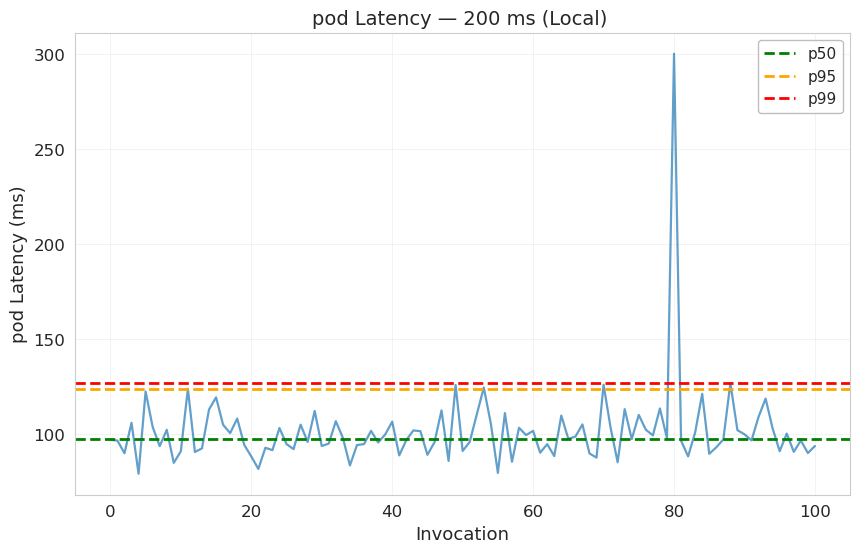

In [21]:
import matplotlib.pyplot as plt
import numpy as np

pod_200 = pd.read_csv("pod_df_200ms.csv")
# Récupérer les durées
durations = pod_200['duration_ms'].dropna().values

# Calcul des percentiles
p50 = np.percentile(durations, 50)
p95 = np.percentile(durations, 95)
p99 = np.percentile(durations, 99)

plt.figure(figsize=(10,6))

# Tracer les durées individuelles
plt.plot(pod_200.index, durations, alpha=0.7)

# Ajouter les lignes horizontales pour les percentiles
plt.axhline(p50, color='green', linestyle='--', linewidth=2, label='p50')
plt.axhline(p95, color='orange', linestyle='--', linewidth=2, label='p95')
plt.axhline(p99, color='red', linestyle='--', linewidth=2, label='p99')

plt.xlabel("Invocation")
plt.ylabel("pod Latency (ms)")
plt.grid(True)
plt.legend()
plt.title("pod Latency — 200 ms (Local) ")
plt.savefig("pod_latencies_percentiles_200ms.pdf", format="pdf")
plt.show()

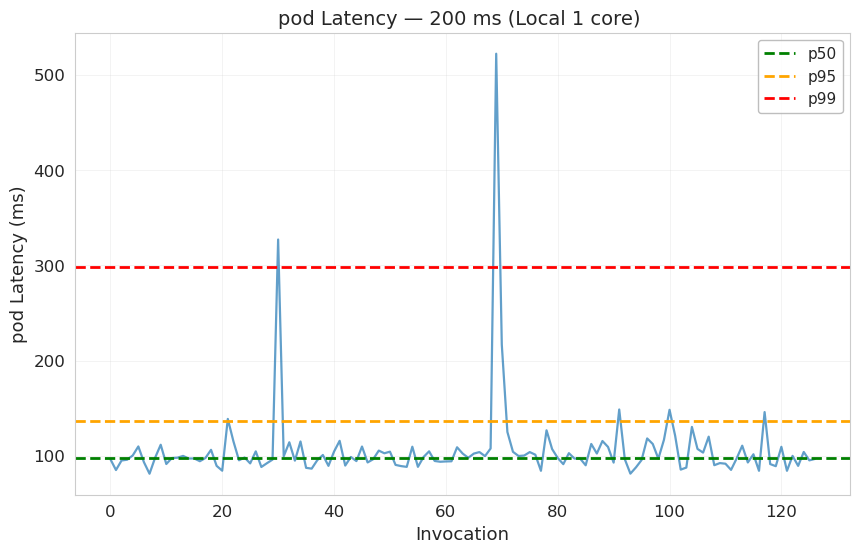

In [22]:
import matplotlib.pyplot as plt
import numpy as np

pod_200_core = pd.read_csv("pod_df_200ms_1core.csv")
# Récupérer les durées
durations = pod_200_core['duration_ms'].dropna().values

# Calcul des percentiles
p50 = np.percentile(durations, 50)
p95 = np.percentile(durations, 95)
p99 = np.percentile(durations, 99)

plt.figure(figsize=(10,6))

# Tracer les durées individuelles
plt.plot(pod_200_core.index, durations, alpha=0.7)

# Ajouter les lignes horizontales pour les percentiles
plt.axhline(p50, color='green', linestyle='--', linewidth=2, label='p50')
plt.axhline(p95, color='orange', linestyle='--', linewidth=2, label='p95')
plt.axhline(p99, color='red', linestyle='--', linewidth=2, label='p99')

plt.xlabel("Invocation")
plt.ylabel("pod Latency (ms)")
plt.grid(True)
plt.legend()
plt.title("pod Latency — 200 ms (Local 1 core) ")
plt.savefig("pod_latencies_percentiles_200ms_core.pdf", format="pdf")
plt.show()

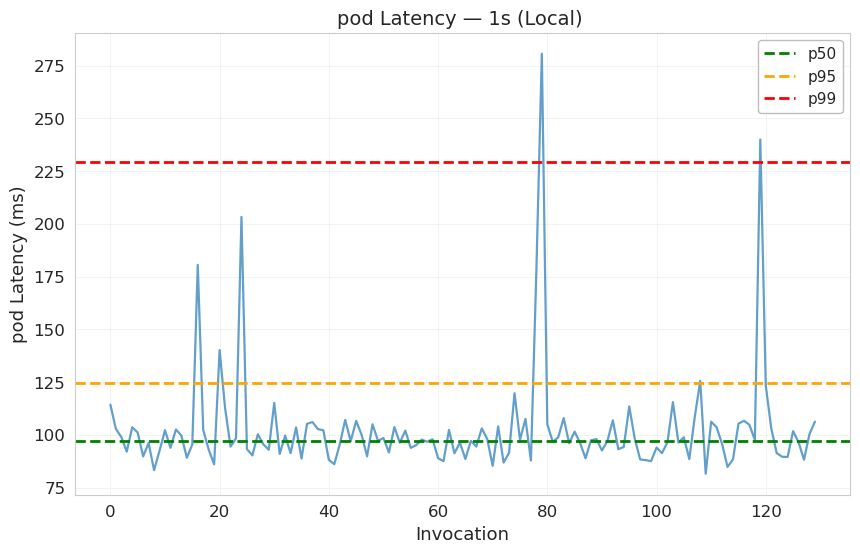

In [23]:
import matplotlib.pyplot as plt
import numpy as np

pod_1 = pd.read_csv("pod_df_1s.csv")
# Récupérer les durées
durations = pod_1['duration_ms'].dropna().values

# Calcul des percentiles
p50 = np.percentile(durations, 50)
p95 = np.percentile(durations, 95)
p99 = np.percentile(durations, 99)

plt.figure(figsize=(10,6))

# Tracer les durées individuelles
plt.plot(pod_1.index, durations, alpha=0.7)

# Ajouter les lignes horizontales pour les percentiles
plt.axhline(p50, color='green', linestyle='--', linewidth=2, label='p50')
plt.axhline(p95, color='orange', linestyle='--', linewidth=2, label='p95')
plt.axhline(p99, color='red', linestyle='--', linewidth=2, label='p99')

plt.xlabel("Invocation")
plt.ylabel("pod Latency (ms)")
plt.grid(True)
plt.legend()
plt.title("pod Latency — 1s (Local) ")
plt.savefig("pod_latencies_percentiles_1s.pdf", format="pdf")
plt.show()

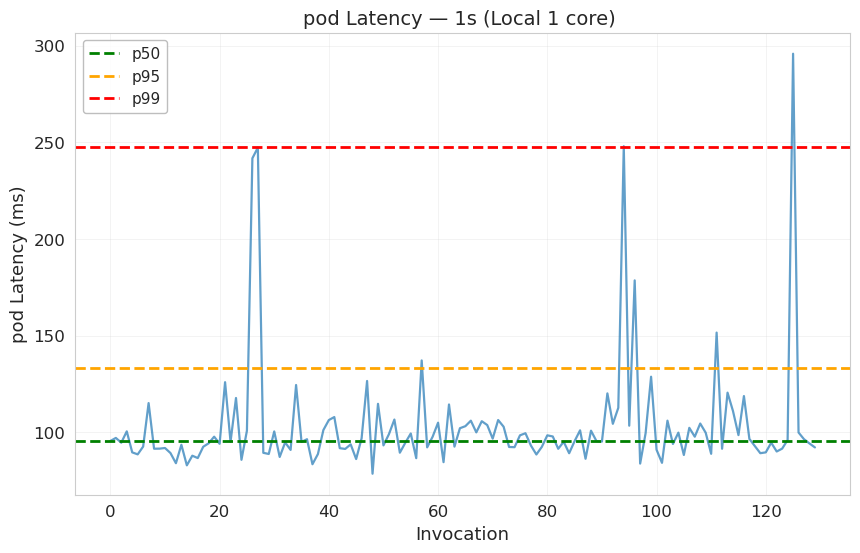

In [25]:
import matplotlib.pyplot as plt
import numpy as np

pod_1_core = pd.read_csv("pod_df_1s_1core.csv")
# Récupérer les durées
durations = pod_1_core['duration_ms'].dropna().values

# Calcul des percentiles
p50 = np.percentile(durations, 50)
p95 = np.percentile(durations, 95)
p99 = np.percentile(durations, 99)

plt.figure(figsize=(10,6))

# Tracer les durées individuelles
plt.plot(pod_1_core.index, durations, alpha=0.7)

# Ajouter les lignes horizontales pour les percentiles
plt.axhline(p50, color='green', linestyle='--', linewidth=2, label='p50')
plt.axhline(p95, color='orange', linestyle='--', linewidth=2, label='p95')
plt.axhline(p99, color='red', linestyle='--', linewidth=2, label='p99')

plt.xlabel("Invocation")
plt.ylabel("pod Latency (ms)")
plt.grid(True)
plt.legend()
plt.title("pod Latency — 1s (Local 1 core) ")
plt.savefig("pod_latencies_percentiles_1s_core.pdf", format="pdf")
plt.show()